# Testing the `Intent Classification` n8n Workflow

Given a user message, the last AI message, and the previous AI agent, the workflow
routes the conversation to one of four destinations:

| Route | Meaning |
|---|---|
| `advisor` | Customer needs a personalised debt plan or action |
| `education` | Customer is asking a general debt-knowledge question |
| `summary` | Customer wants a summary of previous advice |
| `unknown` | Out-of-scope or ambiguous message |

### Evaluation approach
This is a **multi-class single-label** problem. The ground-truth label is
`expected_route`; the model prediction is `result_route_to`. Metrics are reported
both overall and per class (one-vs-rest precision / recall / F1) to surface
which routes are hardest for the model.

Results are written to **`test_result.xlsx`** (two sheets):
- **`test_result`** — every row from `classification_result.xlsx` extended with
  `is_correct` and `mismatch_detail`.
- **`overview`** — comprehensive summary: overall accuracy, per-class metrics,
  confusion matrix, and class-distribution tables.

In [1]:
import json
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import requests
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm.notebook import tqdm

## 1. Configuration

In [2]:
RESULT_XLSX   = Path("../actual_test_cases/classification_result.xlsx")
OUTPUT_XLSX   = Path("classification_eval_results.xlsx")

CLASSES       = ["advisor", "education", "summary", "unknown"]
EXPECTED_COL  = "expected_route"
PREDICTED_COL = "result_route_to"

## 2. Load the classification result

In [3]:
df = pd.read_excel(RESULT_XLSX)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(5)

Loaded 250 rows  |  columns: ['testId', 'userMessage', 'LastAImessage', 'PrevAIagent', 'narrative', 'expected_route', 'reason', 'result_route_to', 'result_narrative', 'error']


,testId,userMessage,LastAImessage,PrevAIagent,narrative,expected_route,reason,result_route_to,result_narrative,error
0,TC-0001,ตอนนี้โบนัสถูกเลื่อน เลยอยากถามว่าอยากลดค่างวด...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,Customer raises a personal debt-management sit...,advisor,Customer requests a personalized debt solution...,advisor,The customer states their bonus has been postp...,NaN
1,TC-0002,ถ้าสถานการณ์คือโบนัสถูกเลื่อน แบบนี้ คุณช่วยแน...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,Customer raises a personal debt-management sit...,advisor,Customer requests a personalized debt solution...,advisor,The advisor proposed a restructuring plan. The...,NaN
2,TC-0003,แผนที่ให้มาดูดีนะคะ แต่พอดีโบนัสถูกเลื่อน เลยอ...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,Customer raises a personal debt-management sit...,advisor,Customer requests a personalized debt solution...,advisor,The advisor proposed a debt plan. The customer...,NaN
3,TC-0004,ขอพูดตรง ๆ ว่าโบนัสถูกเลื่อน ตอนนี้เลยอยากให้ช...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,Customer raises a personal debt-management sit...,advisor,Customer requests a personalized debt solution...,advisor,The customer states their bonus has been postp...,NaN
4,TC-0005,ผมไม่ได้อยากหนีหนี้นะครับ แต่โบนัสถูกเลื่อน ช่...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,Customer raises a personal debt-management sit...,advisor,Customer requests a personalized debt solution...,advisor,The customer states their bonus has been delay...,NaN


In [4]:
# Class distribution — ground truth vs predictions
dist = pd.DataFrame({
    "expected_count" : df[EXPECTED_COL].value_counts(),
    "predicted_count": df[PREDICTED_COL].value_counts(),
}).reindex(CLASSES).fillna(0).astype(int)
dist["delta"] = dist["predicted_count"] - dist["expected_count"]
print("Class distribution")
dist

Class distribution


,expected_count,predicted_count,delta
advisor,103,94,-9
education,68,83,15
summary,30,31,1
unknown,49,42,-7


## 3. Evaluate — accuracy, per-class precision / recall / F1, confusion matrix

In [5]:
# Filter out rows with errors
valid = df[df["error"].isna()].copy()
skipped = len(df) - len(valid)
if skipped:
    print(f"⚠️  {skipped} row(s) had errors and were excluded from metrics.")

y_true = valid[EXPECTED_COL].str.lower().str.strip()
y_pred = valid[PREDICTED_COL].str.lower().str.strip()

overall_accuracy = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy : {overall_accuracy:.4f}  ({int(overall_accuracy * len(valid))}/{len(valid)})")

Overall Accuracy : 0.8520  (213/250)


In [6]:
# Per-class metrics (one-vs-rest)
def per_class_metrics(y_true, y_pred, classes):
    rows = []
    for cls in classes:
        yt = (y_true == cls)
        yp = (y_pred == cls)
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[False, True]).ravel()
        rows.append({
            "route"      : cls,
            "support"    : int(yt.sum()),
            "TP"         : int(tp),
            "FP"         : int(fp),
            "FN"         : int(fn),
            "TN"         : int(tn),
            "precision"  : round(precision_score(yt, yp, zero_division=0), 4),
            "recall"     : round(recall_score(yt, yp, zero_division=0), 4),
            "f1"         : round(f1_score(yt, yp, zero_division=0), 4),
            "specificity": round(tn / (tn + fp), 4) if (tn + fp) > 0 else float("nan"),
        })
    metrics_df = pd.DataFrame(rows)

    # Macro averages
    macro_row = {
        "route"      : "macro avg",
        "support"    : len(y_true),
        "TP"         : metrics_df["TP"].sum(),
        "FP"         : metrics_df["FP"].sum(),
        "FN"         : metrics_df["FN"].sum(),
        "TN"         : metrics_df["TN"].sum(),
        "precision"  : round(metrics_df["precision"].mean(), 4),
        "recall"     : round(metrics_df["recall"].mean(), 4),
        "f1"         : round(metrics_df["f1"].mean(), 4),
        "specificity": round(metrics_df["specificity"].mean(), 4),
    }
    return pd.concat([metrics_df, pd.DataFrame([macro_row])], ignore_index=True)


metrics_df = per_class_metrics(y_true, y_pred, CLASSES)
metrics_df

,route,support,TP,FP,FN,TN,precision,recall,f1,specificity
0,advisor,103,82,12,21,135,0.8723,0.7961,0.8325,0.9184
1,education,68,68,15,0,167,0.8193,1.0000,0.9007,0.9176
2,summary,30,22,9,8,211,0.7097,0.7333,0.7213,0.9591
3,unknown,49,41,1,8,200,0.9762,0.8367,0.9011,0.9950
4,macro avg,250,213,37,37,713,0.8444,0.8415,0.8389,0.9475


## 4. Confusion matrix heatmap (multi-class)

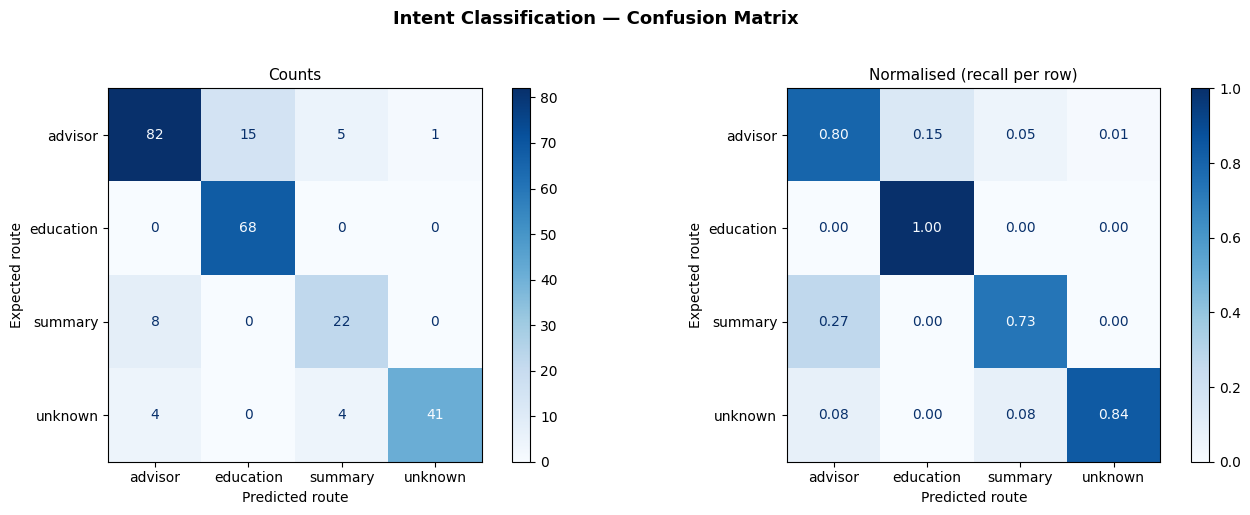

In [7]:
def plot_confusion_matrix(y_true, y_pred, classes, title="Intent Classification — Confusion Matrix"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, normalize, subtitle in zip(
        axes,
        [None, "true"],
        ["Counts", "Normalised (recall per row)"],
    ):
        cm_plot = confusion_matrix(y_true, y_pred, labels=classes, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm_plot, display_labels=classes)
        disp.plot(ax=ax, colorbar=True,
                  cmap="Blues",
                  values_format=".2f" if normalize else "d")
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel("Predicted route", fontsize=10)
        ax.set_ylabel("Expected route", fontsize=10)

    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_confusion_matrix(y_true, y_pred, CLASSES)

## 5. Per-class metric bar chart

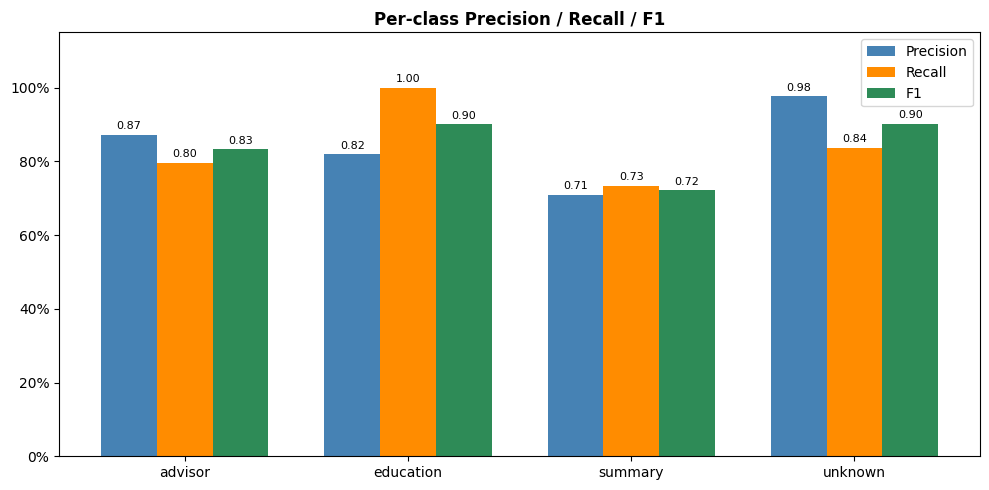

In [8]:
def plot_per_class_metrics(metrics_df, classes):
    per_class = metrics_df[metrics_df["route"].isin(classes)].set_index("route")
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(classes))
    width = 0.25
    bars = [
        ax.bar(x - width, per_class.loc[classes, "precision"], width, label="Precision", color="steelblue"),
        ax.bar(x,         per_class.loc[classes, "recall"],    width, label="Recall",    color="darkorange"),
        ax.bar(x + width, per_class.loc[classes, "f1"],        width, label="F1",        color="seagreen"),
    ]
    for bar_group in bars:
        for bar in bar_group:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("Per-class Precision / Recall / F1", fontsize=12, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("per_class_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_per_class_metrics(metrics_df, CLASSES)

## 6. Mismatch inspection

In [9]:
mismatch_mask = y_true.values != y_pred.values
mismatches = valid[mismatch_mask].copy()
print(f"{len(mismatches)} row(s) with wrong prediction  "
      f"(out of {len(valid)} valid rows).\n")

for cls in CLASSES:
    fn_rows = valid[(y_true == cls) & (y_pred != cls)]
    fp_rows = valid[(y_true != cls) & (y_pred == cls)]
    if fn_rows.empty and fp_rows.empty:
        continue
    print(f"{'='*70}")
    print(f"[{cls}]  FN={len(fn_rows)}  FP={len(fp_rows)}")
    if not fn_rows.empty:
        print("  -- False Negatives (expected this route, predicted something else) --")
        for _, r in fn_rows.iterrows():
            print(f"    [{r['testId']}] predicted='{r[PREDICTED_COL]}' | {str(r['userMessage'])[:70]}")
    if not fp_rows.empty:
        print("  -- False Positives (predicted this route, but expected something else) --")
        for _, r in fp_rows.iterrows():
            print(f"    [{r['testId']}] expected='{r[EXPECTED_COL]}' | {str(r['userMessage'])[:70]}")
print("="*70)

37 row(s) with wrong prediction  (out of 250 valid rows).

[advisor]  FN=21  FP=12
  -- False Negatives (expected this route, predicted something else) --
    [TC-0104] predicted='education' | ขอถามเป็นความรู้ก่อนนะครับ เรื่องการพักชำระหนี้ ต่างจากการลดค่างวดหรือ
    [TC-0106] predicted='education' | อธิบายให้ฟังหน่อยได้ไหมว่าการพักชำระหนี้ ต่างจากการลดค่างวดหรือไม่
    [TC-0108] predicted='education' | ช่วยสรุปแบบภาษาคนทั่วไปได้ไหมว่าการพักชำระหนี้ ต่างจากการลดค่างวดหรือไ
    [TC-0109] predicted='education' | ขอถามเป็นความรู้ก่อนนะครับ เรื่องการรวมหนี้ มีข้อดีข้อเสียอะไรบ้าง
    [TC-0111] predicted='education' | อธิบายให้ฟังหน่อยได้ไหมว่าการรวมหนี้ มีข้อดีข้อเสียอะไรบ้าง
    [TC-0113] predicted='education' | ช่วยสรุปแบบภาษาคนทั่วไปได้ไหมว่าการรวมหนี้ มีข้อดีข้อเสียอะไรบ้าง
    [TC-0114] predicted='education' | ขอถามเป็นความรู้ก่อนนะครับ เรื่องดอกเบี้ยผิดนัด คิดจากยอดไหนและเริ่มเม
    [TC-0116] predicted='education' | อธิบายให้ฟังหน่อยได้ไหมว่าดอกเบี้ยผิดนัด คิดจากยอดไหนและเริ่มเมื่อไร

## 7. Save results to Excel

- **`overview` sheet** — high-level summary, per-class metrics table, confusion matrix, and class distribution.
- **`test_result` sheet** — all original columns extended with `is_correct` and `mismatch_detail`.

In [10]:
# --- Build test_result sheet ---
results_df = df.copy()
results_df["is_correct"] = (
    results_df[EXPECTED_COL].str.lower().str.strip()
    == results_df[PREDICTED_COL].str.lower().str.strip()
)
results_df["mismatch_detail"] = results_df.apply(
    lambda r: (
        f"expected '{r[EXPECTED_COL]}' → got '{r[PREDICTED_COL]}'"
        if not r["is_correct"] else ""
    ),
    axis=1,
)

print(f"test_result sheet: {len(results_df)} rows")
results_df[["testId", EXPECTED_COL, PREDICTED_COL, "is_correct", "mismatch_detail"]].head(10)

test_result sheet: 250 rows


,testId,expected_route,result_route_to,is_correct,mismatch_detail
0,TC-0001,advisor,advisor,True,
1,TC-0002,advisor,advisor,True,
2,TC-0003,advisor,advisor,True,
3,TC-0004,advisor,advisor,True,
4,TC-0005,advisor,advisor,True,
5,TC-0006,advisor,advisor,True,
6,TC-0007,advisor,advisor,True,
7,TC-0008,advisor,advisor,True,
8,TC-0009,advisor,advisor,True,
9,TC-0010,advisor,advisor,True,


In [11]:
# --- Build overview data ---
n_valid   = len(valid)
n_correct = int((y_true.values == y_pred.values).sum())
n_errors  = skipped

summary_rows = [
    ["CLASSIFICATION EVALUATION OVERVIEW", ""],
    ["", ""],
    ["Run date",            pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")],
    ["Source file",         str(RESULT_XLSX.name)],
    ["Total test cases",    len(df)],
    ["Valid (no error)",    n_valid],
    ["Rows with errors",    n_errors],
    ["Correct predictions", n_correct],
    ["Wrong predictions",   n_valid - n_correct],
    ["Overall Accuracy",    round(overall_accuracy, 4)],
]
summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

metrics_export = metrics_df.rename(columns={
    "route"      : "Route",
    "support"    : "Support (GT)",
    "precision"  : "Precision",
    "recall"     : "Recall",
    "f1"         : "F1",
    "specificity": "Specificity",
})

cm_df = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=CLASSES),
    index=[f"actual_{c}" for c in CLASSES],
    columns=[f"pred_{c}" for c in CLASSES],
)

dist.index.name = "Route"
dist_export = dist.reset_index()

# --- Write Excel ---
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:

    # overview sheet
    row_cursor = 0
    summary_df.to_excel(writer, sheet_name="overview",
                        index=False, startrow=row_cursor)
    row_cursor += len(summary_df) + 2

    pd.DataFrame([["PER-CLASS METRICS"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    metrics_export.to_excel(writer, sheet_name="overview",
                            index=False, startrow=row_cursor)
    row_cursor += len(metrics_export) + 2

    pd.DataFrame([["CONFUSION MATRIX (rows=actual, cols=predicted)"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    cm_df.to_excel(writer, sheet_name="overview", startrow=row_cursor)
    row_cursor += len(cm_df) + 2

    pd.DataFrame([["CLASS DISTRIBUTION"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    dist_export.to_excel(writer, sheet_name="overview",
                         index=False, startrow=row_cursor)

    # test_result sheet
    results_df.to_excel(writer, sheet_name="test_result", index=False)

print(f"Saved → {OUTPUT_XLSX}")
print(f"  Sheets: overview, test_result")

Saved → test_result.xlsx
  Sheets: overview, test_result


## 8. Inline classification report

In [12]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, labels=CLASSES, zero_division=0))
print(f"Overall Accuracy: {overall_accuracy:.4f}  ({n_correct}/{n_valid})")
print("=" * 60)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     advisor       0.87      0.80      0.83       103
   education       0.82      1.00      0.90        68
     summary       0.71      0.73      0.72        30
     unknown       0.98      0.84      0.90        49

    accuracy                           0.85       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.86      0.85      0.85       250

Overall Accuracy: 0.8520  (213/250)


---

# LLM-as-a-Judge: Narrative Quality Evaluation

Evaluates the `result_narrative` field generated by the intent-classification agent
using the **calibrated judge prompt** (`prompt_1`) obtained from the alignment phase
in `LLM_judge_alignment/aligned_classification.ipynb`.

**Why prompt_1?**  
After 2 optimisation rounds the mismatch vs. golden labels converged to ≤ 30 %:

| Prompt | narrative mismatch |
|--------|-------------------|
| prompt_0 | 70.0 % ✗ |
| **prompt_1** | **16.7 %** ✓ |

**Scoring scale:** `"good"` / `"acceptable"` / `"invalid"`  
**Score field:** `narrative`

**Rating criteria:**
- `good` — Accurate, concise, and specific. Captures the customer's exact situation/quote; immediately useful to the next agent.
- `acceptable` — Directionally correct but too generic or formulaic; missing specific context from the user's message.
- `invalid` — Factually wrong: misrepresents what the customer said, fabricates context, or contradicts the correct route.

## 9. Configuration — LLM Judge

In [13]:
N8N_BASE_URL      = "https://alphamakeathon-automation.arisetech.dev"
JUDGE_WEBHOOK     = "9d6049fc-77c8-43e9-b71e-f734506f4f9d"
USE_TEST_URL      = False

JUDGE_OUTPUT_FILE = Path("classification_narrative_results.xlsx")
JUDGE_SCORE_FIELD = "narrative"
LABEL_ORDER       = ["good", "acceptable", "invalid"]
LABEL_COLORS      = {"good": "#4caf50", "acceptable": "#ff9800", "invalid": "#f44336"}
JUDGE_TIMEOUT     = 600
JUDGE_RETRIES     = 2
JUDGE_DELAY       = 0.5    # seconds between rows

GROUP_COL         = "expected_route"   # analogous to ragFocus in education


def get_judge_url() -> str:
    prefix = "webhook-test" if USE_TEST_URL else "webhook"
    return f"{N8N_BASE_URL}/{prefix}/{JUDGE_WEBHOOK}"


print("Judge webhook URL:", get_judge_url())

Judge webhook URL: https://alphamakeathon-automation.arisetech.dev/webhook/9d6049fc-77c8-43e9-b71e-f734506f4f9d


## 10. Calibrated Judge Prompt — `prompt_1`

This is the final output of the alignment loop in `aligned_classification.ipynb`.  
Placeholders: **`{userMessage}`**, **`{LastAImessage}`**, **`{PrevAIagent}`**,
**`{narrative}`**, **`{expected_route}`**, **`{reason}`**, **`{result_narrative}`**.  
Returns JSON with `narrative` valued **`"good"`** / **`"acceptable"`** / **`"invalid"`**.

In [14]:
JUDGE_PROMPT = """\
You are a Quality Assurance (QA) expert evaluating AI-generated routing narratives for a Thai bank chatbot system.

The chatbot classifies customer messages and routes them to the appropriate agent:
- "advisor"   : customer needs a personalised debt solution or restructuring plan.
- "education" : customer asks a general question about products or programmes.
- "summary"   : staff has requested a case summary.
- "unknown"   : intent is unclear or off-topic.

Along with the routing decision, the system generates a brief narrative that describes the conversation context and the customer's intent. Your task is to evaluate whether this generated narrative is accurate and useful for the next agent receiving the case.

## Conversation Context

Customer's Latest Message:
{userMessage}

Previous AI Message:
{LastAImessage}

Previous Agent Type:
{PrevAIagent}

Running Conversation Narrative (from prior turns):
{narrative}

## Classification Result

Correct Route:
{expected_route}

Routing Reason:
{reason}

Generated Narrative to Evaluate:
{result_narrative}

## Evaluation Criteria
Assume the provided `Correct Route` is the ground truth. Your goal is to assess the quality of the `Generated Narrative` based on its accuracy and utility. Evaluate using the following definitions, in order.

### narrative — Quality of the generated routing narrative

- "good"       : The narrative is accurate, concise, and immediately useful. It correctly reflects the customer's intent (aligning with `Correct Route`) and, crucially, captures the customer's specific request or situation, often by directly quoting {userMessage}. A structured format like "Customer's intent is {route}... Latest request: '{quote}'" is considered **good** because this verbatim context is highly valuable for the next agent. The narrative effectively combines correct classification with specific, actionable context.

- "acceptable" : The narrative supports the correct routing decision but lacks specific details, making it less useful. It might be too generic or formulaic, for example, stating "Customer needs advice" without including the actual question they asked. It is directionally correct but omits the key context from the user's message that a "good" narrative would contain.

- "invalid"    : The narrative is factually wrong or misleading. It misrepresents the customer's statements (e.g., claims they accepted an offer when they did not), fabricates information not present in the conversation, or directly contradicts the provided `Correct Route`.

## Output Instructions
Return ONLY a JSON object — no markdown, no explanation:
{
  "narrative": "good" | "acceptable" | "invalid"
}"""

print(f"Judge prompt loaded: {len(JUDGE_PROMPT)} chars")

Judge prompt loaded: 2672 chars


## 11. Helper Functions

In [15]:
_PROMPT_FIELDS = [
    "userMessage", "LastAImessage", "PrevAIagent", "narrative",
    "expected_route", "reason", "result_narrative",
]


def fill_judge_prompt(template: str, row: pd.Series) -> str:
    filled = template
    for col in _PROMPT_FIELDS:
        filled = filled.replace(f"{{{col}}}", str(row.get(col, "") or ""))
    return filled


def _call_raw(payload: dict, timeout: int = JUDGE_TIMEOUT, retries: int = JUDGE_RETRIES):
    url = get_judge_url()
    last_exc: Exception | None = None
    for attempt in range(retries + 1):
        try:
            resp = requests.post(url, json=payload, timeout=timeout)
            resp.raise_for_status()
            return resp.json()
        except requests.exceptions.RequestException as exc:
            last_exc = exc
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
    raise last_exc


def call_webhook(prompt: str):
    return _call_raw({"input": prompt})


def get_response_text(resp) -> str:
    if isinstance(resp, str):
        return resp
    if isinstance(resp, dict):
        for key in ("output", "text", "result", "response", "content", "message"):
            if key in resp and resp[key] is not None:
                return str(resp[key])
        return json.dumps(resp, ensure_ascii=False)
    return str(resp)


def parse_json_response(resp) -> dict:
    text = get_response_text(resp)
    m = re.search(r"```(?:json)?\s*([\s\S]*?)\s*```", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    m = re.search(r"(\{[\s\S]*?\})", text)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    return {}


print("Helpers ready.")

Helpers ready.


## 12. Run Narrative Evaluation

For each row in `classification_result.xlsx`:
1. Fill all placeholders into the calibrated judge prompt.
2. POST `{"input": filled_prompt}` to the webhook.
3. Parse JSON response → extract `narrative` score.
4. Save full results to `narrative_eval_results.xlsx`.

If `narrative_eval_results.xlsx` already exists, evaluation is **skipped** and the existing file is loaded.

In [16]:
if JUDGE_OUTPUT_FILE.exists():
    print(f"Results already exist → {JUDGE_OUTPUT_FILE}  (skipping evaluation)")
    df_judge = pd.read_excel(JUDGE_OUTPUT_FILE)
else:
    predicted: list[str | None] = []
    errors:    list[str | None] = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Narrative eval"):
        try:
            filled = fill_judge_prompt(JUDGE_PROMPT, row)
            raw    = call_webhook(filled)
            parsed = parse_json_response(raw)
            predicted.append(parsed.get(JUDGE_SCORE_FIELD))
            errors.append(None)
        except Exception as exc:
            predicted.append(None)
            errors.append(str(exc))
        time.sleep(JUDGE_DELAY)

    df_judge = df[
        ["testId", "userMessage", "LastAImessage", "PrevAIagent",
         "narrative", "expected_route", "reason", "result_narrative"]
    ].copy()
    df_judge[JUDGE_SCORE_FIELD] = predicted
    df_judge["judge_error"]     = errors

    df_judge.to_excel(JUDGE_OUTPUT_FILE, index=False)
    print(f"Saved → {JUDGE_OUTPUT_FILE}")

total_rows   = len(df_judge)
error_count  = df_judge["judge_error"].notna().sum() if "judge_error" in df_judge.columns else 0
print(f"\nTotal rows evaluated : {total_rows}")
print(f"Errors / parse fails : {error_count}")
df_judge.head(3)

Results already exist → narrative_eval_results.xlsx  (skipping evaluation)

Total rows evaluated : 250
Errors / parse fails : 0


,testId,userMessage,LastAImessage,PrevAIagent,narrative,expected_route,reason,result_narrative,judge_error
0,TC-0001,ตอนนี้โบนัสถูกเลื่อน เลยอยากถามว่าอยากลดค่างวด...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,acceptable,advisor,Customer requests a personalized debt solution...,The customer states their bonus has been postp...,NaN
1,TC-0002,ถ้าสถานการณ์คือโบนัสถูกเลื่อน แบบนี้ คุณช่วยแน...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,good,advisor,Customer requests a personalized debt solution...,The advisor proposed a restructuring plan. The...,NaN
2,TC-0003,แผนที่ให้มาดูดีนะคะ แต่พอดีโบนัสถูกเลื่อน เลยอ...,เสนอแผนการปรับโครงสร้างสินเชื่อ ด้วยแผนงานและข...,ADVISOR,good,advisor,Customer requests a personalized debt solution...,The advisor proposed a debt plan. The customer...,NaN


## 13. Results Summary

### Overall score distribution

In [17]:
counts = df_judge[JUDGE_SCORE_FIELD].value_counts()
total  = counts.sum()

print("=" * 55)
print("SCORE DISTRIBUTION — narrative  (all test cases)")
print("=" * 55)
for lbl in LABEL_ORDER:
    n = counts.get(lbl, 0)
    bar = "█" * int(n / total * 40)
    print(f"  {lbl:12s}: {n:4d}  ({n/total:5.1%})  {bar}")

summary_rows = []
for lbl in LABEL_ORDER:
    n = counts.get(lbl, 0)
    summary_rows.append({"label": lbl, "count": n, "pct": f"{n/total:.1%}"})
pd.DataFrame(summary_rows)

SCORE DISTRIBUTION — narrative  (all test cases)
  good        :  156  (62.4%)  ████████████████████████
  acceptable  :   67  (26.8%)  ██████████
  invalid     :   27  (10.8%)  ████


,label,count,pct
0,good,156,62.4%
1,acceptable,67,26.8%
2,invalid,27,10.8%


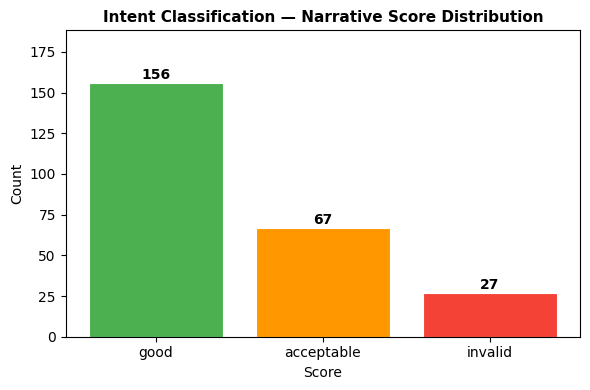

Chart saved → narrative_score_distribution.png


In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
counts_plot = df_judge[JUDGE_SCORE_FIELD].value_counts().reindex(LABEL_ORDER, fill_value=0)
colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
bars   = ax.bar(LABEL_ORDER, counts_plot.values, color=colors, edgecolor="white", linewidth=0.8)
ax.set_title("Intent Classification — Narrative Score Distribution",
             fontweight="bold", fontsize=11)
ax.set_xlabel("Score")
ax.set_ylabel("Count")
for bar, val in zip(bars, counts_plot.values):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            str(val),
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )
ax.set_ylim(0, max(counts_plot.values) * 1.2 + 1)
plt.tight_layout()
plt.savefig("narrative_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → narrative_score_distribution.png")

### Score distribution by route

In [19]:
route_groups = sorted(df_judge[GROUP_COL].dropna().unique())

print("=" * 55)
print(f"SCORE DISTRIBUTIONS — by {GROUP_COL}")
print("=" * 55)
for route in route_groups:
    sub = df_judge[df_judge[GROUP_COL] == route]
    c   = sub[JUDGE_SCORE_FIELD].value_counts()
    t   = c.sum()
    print(f"\n  {GROUP_COL}: {route}  (n={len(sub)})")
    for lbl in LABEL_ORDER:
        n = c.get(lbl, 0)
        print(f"    {lbl:12s}: {n} ({n/t:.0%})", end="  ")
    print()

SCORE DISTRIBUTIONS — by expected_route

  expected_route: advisor  (n=103)
    good        : 61 (59%)      acceptable  : 33 (32%)      invalid     : 9 (9%)  

  expected_route: education  (n=68)
    good        : 43 (63%)      acceptable  : 17 (25%)      invalid     : 8 (12%)  

  expected_route: summary  (n=30)
    good        : 20 (67%)      acceptable  : 6 (20%)      invalid     : 4 (13%)  

  expected_route: unknown  (n=49)
    good        : 32 (65%)      acceptable  : 11 (22%)      invalid     : 6 (12%)  


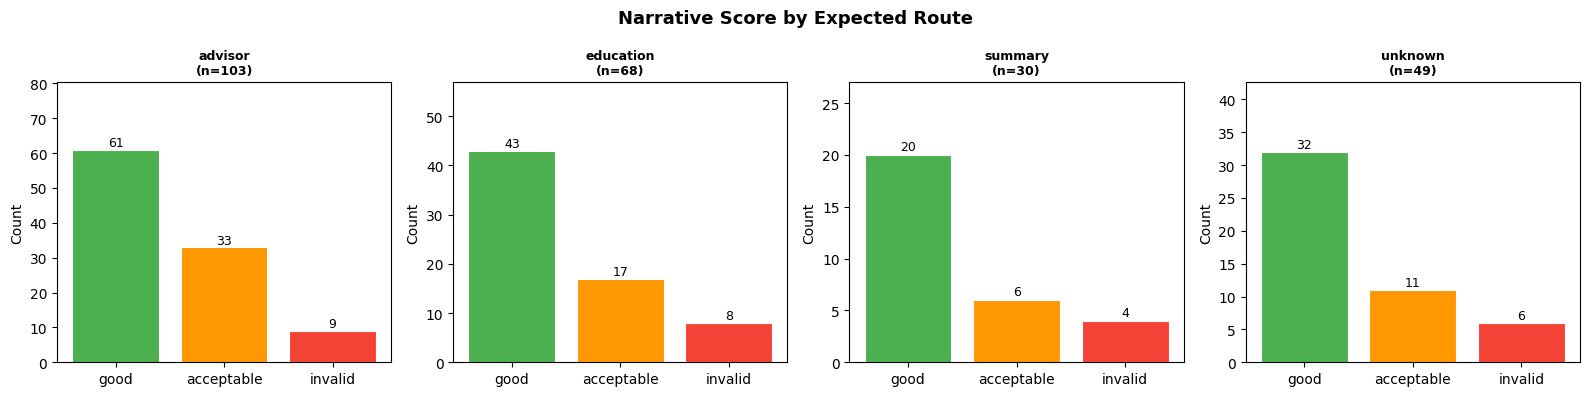

Chart saved → narrative_score_by_route.png


In [20]:
n_routes = len(route_groups)
fig, axes = plt.subplots(1, n_routes, figsize=(4 * n_routes, 4), sharey=False)
if n_routes == 1:
    axes = [axes]

fig.suptitle("Narrative Score by Expected Route", fontsize=13, fontweight="bold")

for ax, route in zip(axes, route_groups):
    sub    = df_judge[df_judge[GROUP_COL] == route]
    c      = sub[JUDGE_SCORE_FIELD].value_counts().reindex(LABEL_ORDER, fill_value=0)
    colors = [LABEL_COLORS[lbl] for lbl in LABEL_ORDER]
    bars   = ax.bar(LABEL_ORDER, c.values, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{route}\n(n={len(sub)})", fontsize=9, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, c.values):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                str(val),
                ha="center", va="bottom", fontsize=9,
            )
    ax.set_ylim(0, max(c.values) * 1.3 + 1)

plt.tight_layout()
plt.savefig("narrative_score_by_route.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → narrative_score_by_route.png")

### Pass rate (good + acceptable) per route

In [21]:
print("=" * 55)
print("PASS RATE  (good + acceptable)")
print("=" * 55)

pass_rows = []
# Overall
for scope, sub in [("overall", df_judge)] + [(r, df_judge[df_judge[GROUP_COL] == r]) for r in route_groups]:
    c      = sub[JUDGE_SCORE_FIELD].value_counts()
    total  = c.sum()
    n_good = c.get("good", 0)
    n_acc  = c.get("acceptable", 0)
    n_inv  = c.get("invalid", 0)
    pass_n = n_good + n_acc
    pass_r = pass_n / total if total else 0
    fail_r = n_inv  / total if total else 0
    label  = f"{scope} (n={total})"
    print(f"  {label:30s}: pass={pass_r:.1%}  "
          f"(good={n_good/total:.1%}, acceptable={n_acc/total:.1%})  |  invalid={fail_r:.1%}")
    pass_rows.append({
        "scope":      scope,
        "total":      int(total),
        "good":       int(n_good),
        "acceptable": int(n_acc),
        "invalid":    int(n_inv),
        "pass_rate":  f"{pass_r:.1%}",
        "fail_rate":  f"{fail_r:.1%}",
    })

df_pass = pd.DataFrame(pass_rows)
df_pass

PASS RATE  (good + acceptable)
  overall (n=250)               : pass=89.2%  (good=62.4%, acceptable=26.8%)  |  invalid=10.8%
  advisor (n=103)               : pass=91.3%  (good=59.2%, acceptable=32.0%)  |  invalid=8.7%
  education (n=68)              : pass=88.2%  (good=63.2%, acceptable=25.0%)  |  invalid=11.8%
  summary (n=30)                : pass=86.7%  (good=66.7%, acceptable=20.0%)  |  invalid=13.3%
  unknown (n=49)                : pass=87.8%  (good=65.3%, acceptable=22.4%)  |  invalid=12.2%


,scope,total,good,acceptable,invalid,pass_rate,fail_rate
0,overall,250,156,67,27,89.2%,10.8%
1,advisor,103,61,33,9,91.3%,8.7%
2,education,68,43,17,8,88.2%,11.8%
3,summary,30,20,6,4,86.7%,13.3%
4,unknown,49,32,11,6,87.8%,12.2%


### Cases flagged `invalid`

In [22]:
df_invalid = df_judge[df_judge[JUDGE_SCORE_FIELD] == "invalid"][
    ["testId", GROUP_COL, "userMessage", "result_narrative", JUDGE_SCORE_FIELD]
].reset_index(drop=True)

print(f"Cases with 'invalid' narrative score: {len(df_invalid)} / {len(df_judge)}")
if len(df_invalid):
    print(f"\nBreakdown by {GROUP_COL}:")
    print(df_invalid[GROUP_COL].value_counts().to_string())
    display(df_invalid)

Cases with 'invalid' narrative score: 27 / 250

Breakdown by expected_route:
expected_route
advisor      9
education    8
unknown      6
summary      4


,testId,expected_route,userMessage,result_narrative,narrative
0,TC-0025,advisor,ผมไม่ได้อยากหนีหนี้นะครับ แต่รายได้จากฟรีแลนซ์...,The customer has an unsecured loan and unstabl...,invalid
1,TC-0034,advisor,ขอพูดตรง ๆ ว่ามีรายจ่ายบ้านเพิ่ม ตอนนี้เลยอยาก...,The advisor previously presented two TDR plans...,invalid
2,TC-0054,advisor,ขอพูดตรง ๆ ว่ากำลังหย่าและต้องแยกค่าใช้จ่าย ตอ...,The customer states they are getting a divorce...,invalid
3,TC-0061,advisor,ตอนนี้พ่อหยุดงานชั่วคราว เลยอยากถามว่าอยากลดค่...,The customer's father has temporarily stopped ...,invalid
4,TC-0072,advisor,ถ้าสถานการณ์คืออยากปิดหนี้ให้เร็วขึ้น แบบนี้ ค...,The customer is asking for a revised debt mana...,invalid
5,TC-0077,advisor,ถ้าสถานการณ์คือรับงานเสริมได้เพิ่ม แบบนี้ คุณช...,The customer has a personal loan and has gaine...,invalid
6,TC-0087,education,ถ้าอ่านเงื่อนไขเองแล้วงง เรื่องTDR ต่างจากการร...,The customer is asking for an explanation of t...,invalid
7,TC-0097,education,ถ้าอ่านเงื่อนไขเองแล้วงง เรื่องปิดหนี้ไวไปต่อไ...,The user is asking for an explanation of how t...,invalid
8,TC-0099,education,ขอถามเป็นความรู้ก่อนนะครับ เรื่องเครดิตบูโร จะ...,The customer is asking an informational questi...,invalid
9,TC-0110,education,ยังไม่ตัดสินใจสมัครค่ะ แค่อยากเข้าใจว่าการรวมห...,The user is not ready to apply for a program a...,invalid


### Cases with `good` narrative

In [23]:
df_good = df_judge[df_judge[JUDGE_SCORE_FIELD] == "good"][
    ["testId", GROUP_COL, JUDGE_SCORE_FIELD]
].reset_index(drop=True)

print(f"Cases with 'good' narrative: {len(df_good)} / {len(df_judge)}  ({len(df_good)/len(df_judge):.1%})")
if len(df_good):
    display(df_good)

Cases with 'good' narrative: 156 / 250  (62.4%)


,testId,expected_route,narrative
0,TC-0002,advisor,good
1,TC-0003,advisor,good
2,TC-0004,advisor,good
3,TC-0008,advisor,good
4,TC-0009,advisor,good
...,...,...,...
151,TC-0243,unknown,good
152,TC-0245,unknown,good
153,TC-0247,unknown,good
154,TC-0248,unknown,good


## 14. Update `test_result.xlsx` with Narrative Scores

Merges the LLM-judge `narrative` score into both sheets of the existing `test_result.xlsx`:
- **`test_result`** — adds `narrative_score` column next to `result_narrative`.
- **`overview`** — appends a narrative summary section at the bottom.

In [24]:
# --- Merge narrative score into the test_result sheet ---
narrative_map = df_judge.set_index("testId")[JUDGE_SCORE_FIELD].to_dict()

results_df["narrative_score"] = results_df["testId"].map(narrative_map)

# --- Rebuild overview narrative section ---
c_ov   = df_judge[JUDGE_SCORE_FIELD].value_counts()
t_ov   = c_ov.sum()
n_good = c_ov.get("good", 0)
n_acc  = c_ov.get("acceptable", 0)
n_inv  = c_ov.get("invalid", 0)

narrative_summary = [
    ["NARRATIVE QUALITY (LLM Judge — prompt_1)", ""],
    ["Judge score field",       JUDGE_SCORE_FIELD],
    ["Total evaluated",         int(t_ov)],
    ["good",                    int(n_good)],
    ["acceptable",              int(n_acc)],
    ["invalid",                 int(n_inv)],
    ["Pass rate (good+accept)", f"{(n_good + n_acc) / t_ov:.1%}" if t_ov else "—"],
    ["Fail rate (invalid)",     f"{n_inv / t_ov:.1%}" if t_ov else "—"],
]

# Per-route breakdown rows
narrative_summary.append(["", ""])
narrative_summary.append(["By expected_route", "good | acceptable | invalid | pass_rate"])
for route in route_groups:
    sub  = df_judge[df_judge[GROUP_COL] == route]
    c    = sub[JUDGE_SCORE_FIELD].value_counts()
    t    = c.sum()
    g, a, i = c.get("good", 0), c.get("acceptable", 0), c.get("invalid", 0)
    narrative_summary.append([
        route,
        f"{g} | {a} | {i} | {(g+a)/t:.1%}" if t else "—"
    ])

df_nar_summary = pd.DataFrame(narrative_summary, columns=["Metric", "Value"])

# --- Write updated Excel ---
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:

    # overview sheet — same structure as before, plus narrative section appended
    row_cursor = 0

    summary_df.to_excel(writer, sheet_name="overview",
                        index=False, startrow=row_cursor)
    row_cursor += len(summary_df) + 2

    pd.DataFrame([["PER-CLASS METRICS (Route Accuracy)"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    metrics_export.to_excel(writer, sheet_name="overview",
                            index=False, startrow=row_cursor)
    row_cursor += len(metrics_export) + 2

    pd.DataFrame([["CONFUSION MATRIX (rows=actual, cols=predicted)"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    cm_df.to_excel(writer, sheet_name="overview", startrow=row_cursor)
    row_cursor += len(cm_df) + 2

    pd.DataFrame([["CLASS DISTRIBUTION"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False,
        startrow=row_cursor)
    row_cursor += 1
    dist_export.to_excel(writer, sheet_name="overview",
                         index=False, startrow=row_cursor)
    row_cursor += len(dist_export) + 2

    df_nar_summary.to_excel(writer, sheet_name="overview",
                            index=False, startrow=row_cursor)

    # test_result sheet — extended with narrative_score
    results_df.to_excel(writer, sheet_name="test_result", index=False)

print(f"Updated → {OUTPUT_XLSX}")
print(f"  test_result columns: {list(results_df.columns)}")

Updated → test_result.xlsx
  test_result columns: ['testId', 'userMessage', 'LastAImessage', 'PrevAIagent', 'narrative', 'expected_route', 'reason', 'result_route_to', 'result_narrative', 'error', 'is_correct', 'mismatch_detail', 'narrative_score']
